── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Rows: 24
Columns: 6
$ Mes                  <chr> "Ene-2024", "Feb-2024", "Mar-2024", "Abr-2024", "…
$ Inversion_Publicidad <dbl> 5000, 7500, 6000, 9000, 8500, 11000, 12000, 10000…
$ Ventas               <dbl> 42000, 55000, 48000, 63000, 61000, 72000, 78000, …
$ Num_Vendedores       <dbl> 8, 8, 9, 10, 10, 11, 11, 12, 12, 13, 13, 14, 9, 1…
$ Satisfaccion_Cliente <dbl> 7.2, 7.5, 7.1, 7.8, 7.6, 8.0, 8.2, 7.9, 8.4, 8.5,…
$ Region               <chr> "Centro", "Centro", "Norte", "Centro", "Sur", "Ce…


        Mes     Inversion_Publicidad     Ventas       Num_Vendedores 
 Length   :24   Min.   : 5000        Min.   : 42000   Min.   : 8.00  
 N.unique :24   1st Qu.: 8875        1st Qu.: 62500   1st Qu.:10.00  
 N.blank  : 0   Median :11750        Median : 76500   Median :11.50  
 Min.nchar: 8   Mean   :12375        Mean   : 80000   Mean   :11.58  
 Max.nchar: 8   3rd Qu.:15250        3rd Qu.: 95750   3rd Qu.:13.00  
                Max.   :22000        Max.   :130000   Max.   :15.00  
 Satisfaccion_Cliente       Region  
 Min.   :7.100        Length   :24  
 1st Qu.:7.675        N.unique : 3  
 Median :8.150        N.blank  : 0  
 Mean   :8.192        Min.nchar: 3  
 3rd Qu.:8.725        Max.nchar: 6  
 Max.   :9.400                      

Mes Inversion_Publicidad               Ventas 
                   0                    0                    0 
      Num_Vendedores Satisfaccion_Cliente               Region 
                   0                    0                    0

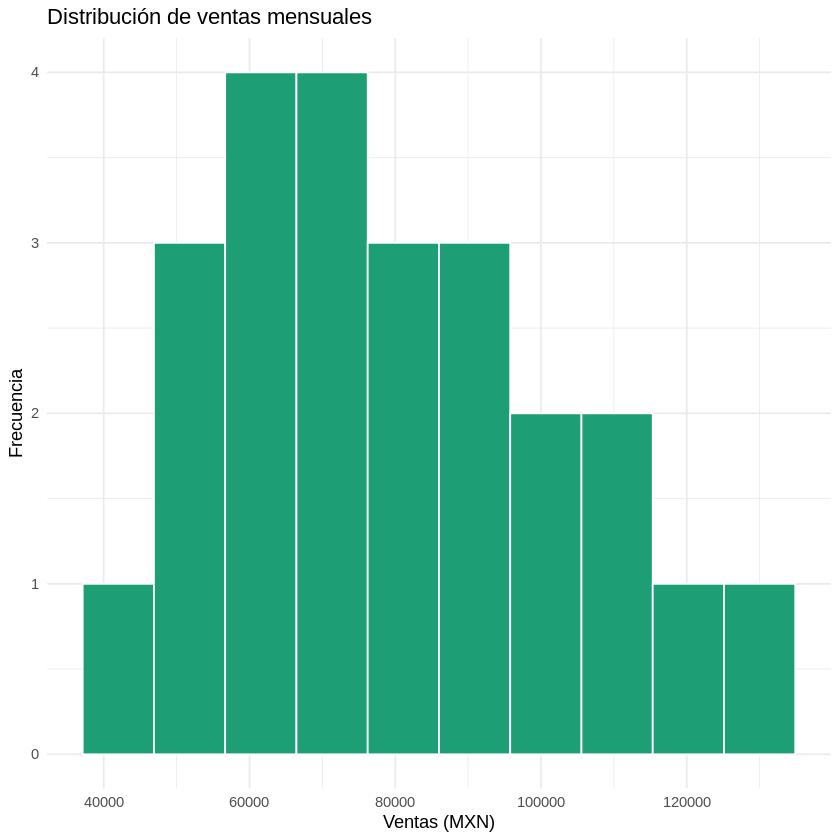

In [1]:
library(tidyverse)
library(readxl)

# 1. Importar la base de datos
datos <- read_excel("Base_Datos_Regresion_BI.xlsx",
                    sheet = "Ventas_Mensuales")

# 2. Explorar estructura y estadísticos descriptivos
glimpse(datos)
summary(datos)

# 3. Verificar valores faltantes
colSums(is.na(datos))

# 4. Visualizar distribución de Ventas
ggplot(datos, aes(x = Ventas)) +
  geom_histogram(bins = 10, fill = "#1D9E75", color = "white") +
  labs(title = "Distribución de ventas mensuales",
       x = "Ventas (MXN)", y = "Frecuencia") +
  theme_minimal()

,Inversion_Publicidad,Ventas,Num_Vendedores,Satisfaccion_Cliente
Inversion_Publicidad,1.0000000,0.9994269,0.9654255,0.9909347
Ventas,0.9994269,1.0000000,0.9639036,0.9887923
Num_Vendedores,0.9654255,0.9639036,1.0000000,0.9639171
Satisfaccion_Cliente,0.9909347,0.9887923,0.9639171,1.0000000


`geom_smooth()` using formula = 'y ~ x'


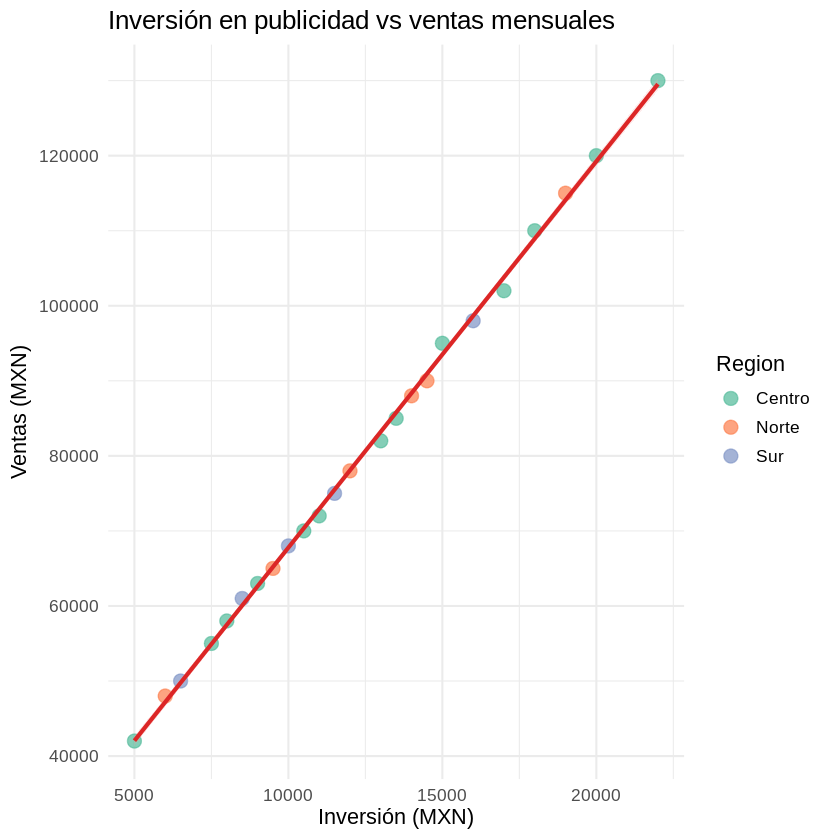

In [2]:
# Correlación entre variables numéricas
datos_num <- datos |>
  select(Inversion_Publicidad, Ventas,
         Num_Vendedores, Satisfaccion_Cliente)

cor(datos_num, method = "pearson")

# Scatter plot: Inversión vs Ventas
ggplot(datos, aes(x = Inversion_Publicidad, y = Ventas,
                  color = Region)) +
  geom_point(size = 3.5, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE,
              color = "#DC2626", fill = "#FCA5A5", alpha = 0.2) +
  labs(title = "Inversión en publicidad vs ventas mensuales",
       x = "Inversión (MXN)", y = "Ventas (MXN)") +
  theme_minimal(base_size = 13) +
  scale_color_brewer(palette = "Set2")

In [3]:
# Modelo: Ventas ~ Inversion_Publicidad
modelo_simple <- lm(Ventas ~ Inversion_Publicidad, data = datos)
summary(modelo_simple)

# Coeficientes e interpretación
coef(modelo_simple)
# Intercepto: ventas esperadas con inversión = 0
# Slope: incremento en Ventas por cada MXN extra de inversión

# R² del modelo
cat("R²:", round(summary(modelo_simple)$r.squared, 4), "\n")
cat("R² Ajustado:", round(summary(modelo_simple)$adj.r.squared, 4), "\n")

# Agregar predicciones y residuos al dataframe
datos <- datos |>
  mutate(
    Prediccion_Simple = round(predict(modelo_simple, datos), 0),
    Residuo_Simple    = round(Ventas - Prediccion_Simple, 0)
  )


Call:
lm(formula = Ventas ~ Inversion_Publicidad, data = datos)

Residuals:
     Min       1Q   Median       3Q      Max 
-1800.38  -536.51    19.42   575.79  1491.68 

Coefficients:
                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)          1.632e+04  4.899e+02   33.31   <2e-16 ***
Inversion_Publicidad 5.146e+00  3.716e-02  138.49   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 827.3 on 22 degrees of freedom
Multiple R-squared:  0.9989,	Adjusted R-squared:  0.9988 
F-statistic: 1.918e+04 on 1 and 22 DF,  p-value: < 2.2e-16


(Intercept) Inversion_Publicidad 
        16317.906683             5.146028

R²: 0.9989 
R² Ajustado: 0.9988 


In [4]:
# Modelo múltiple: Ventas ~ Inversion + Vendedores + Satisfaccion
modelo_multiple <- lm(
  Ventas ~ Inversion_Publicidad + Num_Vendedores + Satisfaccion_Cliente,
  data = datos
)
summary(modelo_multiple)

# Tabla de coeficientes y p-valores
resumen <- summary(modelo_multiple)
coeficientes <- data.frame(
  Variable    = names(coef(modelo_multiple)),
  Coeficiente = round(coef(modelo_multiple), 4),
  P_Valor     = round(resumen$coefficients[, 4], 6)
)
print(coeficientes)

# Métricas del modelo
metricas <- data.frame(
  R2          = round(resumen$r.squared, 4),
  R2_Ajustado = round(resumen$adj.r.squared, 4),
  RMSE        = round(resumen$sigma, 2)
)
print(metricas)

# Agregar predicciones al dataframe
datos <- datos |>
  mutate(
    Prediccion_Multiple = round(predict(modelo_multiple, datos), 0),
    Residuo_Multiple    = round(Ventas - Prediccion_Multiple, 0)
  )


Call:
lm(formula = Ventas ~ Inversion_Publicidad + Num_Vendedores + 
    Satisfaccion_Cliente, data = datos)

Residuals:
     Min       1Q   Median       3Q      Max 
-1645.28  -419.98    34.66   469.23  1903.59 

Coefficients:
                       Estimate Std. Error t value Pr(>|t|)    
(Intercept)          36061.5075 12036.7700   2.996  0.00714 ** 
Inversion_Publicidad     5.6063     0.2838  19.753 1.37e-14 ***
Num_Vendedores         -59.3952   319.1459  -0.186  0.85424    
Satisfaccion_Cliente -3021.5168  1915.1298  -1.578  0.13032    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 813.3 on 20 degrees of freedom
Multiple R-squared:  0.999,	Adjusted R-squared:  0.9988 
F-statistic:  6615 on 3 and 20 DF,  p-value: < 2.2e-16


                                 Variable Coeficiente  P_Valor
(Intercept)                   (Intercept)  36061.5075 0.007141
Inversion_Publicidad Inversion_Publicidad      5.6063 0.000000
Num_Vendedores             Num_Vendedores    -59.3952 0.854236
Satisfaccion_Cliente Satisfaccion_Cliente  -3021.5168 0.130319
     R2 R2_Ajustado   RMSE
1 0.999      0.9988 813.28


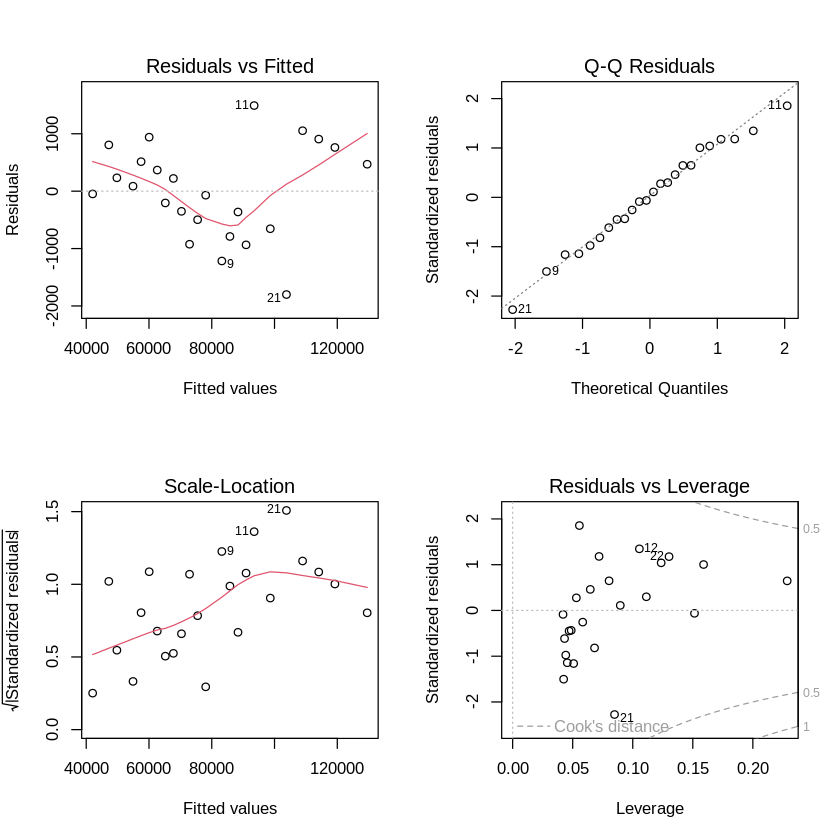


	Shapiro-Wilk normality test

data:  residuals(modelo_simple)
W = 0.98705, p-value = 0.984


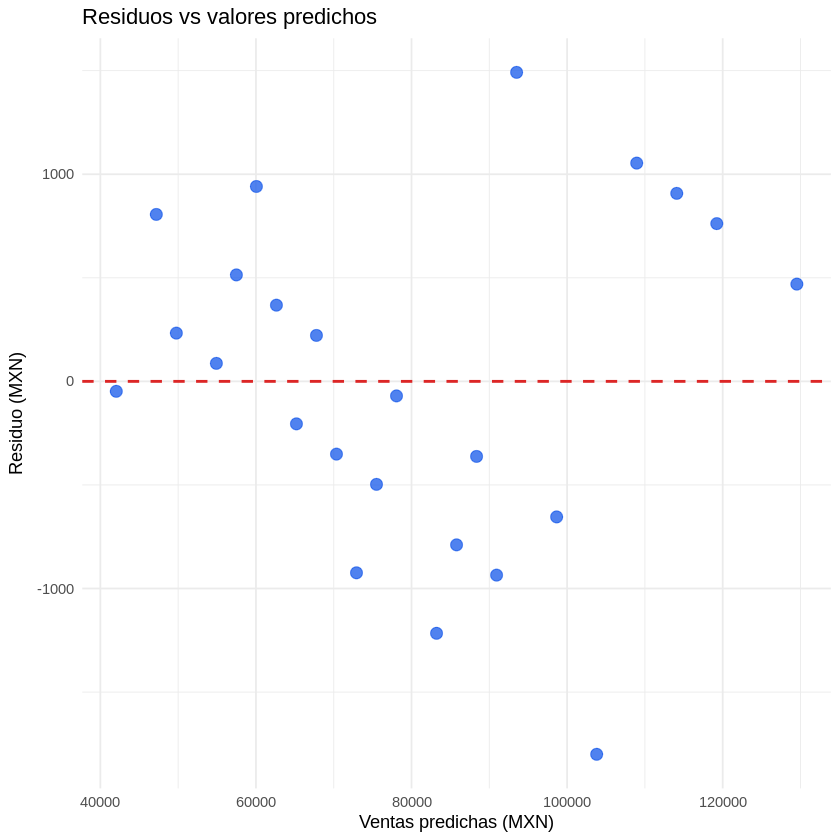

In [5]:
# Diagnóstico visual del modelo simple (4 gráficas)
par(mfrow = c(2, 2))
plot(modelo_simple)
par(mfrow = c(1, 1))

# Gráfica de residuos vs valores predichos (ggplot2)
datos <- datos |>
  mutate(
    Predichos  = fitted(modelo_simple),
    Residuos   = residuals(modelo_simple)
  )

ggplot(datos, aes(x = Predichos, y = Residuos)) +
  geom_point(color = "#2563EB", size = 3, alpha = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed",
             color = "#DC2626", linewidth = 0.8) +
  labs(title = "Residuos vs valores predichos",
       x = "Ventas predichas (MXN)", y = "Residuo (MXN)") +
  theme_minimal()

# Prueba de normalidad de residuos
shapiro.test(residuals(modelo_simple))

  Inversion_Publicidad Num_Vendedores Satisfaccion_Cliente Venta_Estimada
1                10000             11                  8.0          67299
2                15000             12                  8.5          93760
3                20000             14                  9.0         120162
4                25000             15                  9.2         147530
  IC_Inferior IC_Superior
1       66574       68024
2       93119       94402
3      118802      121522
4      144140      150919


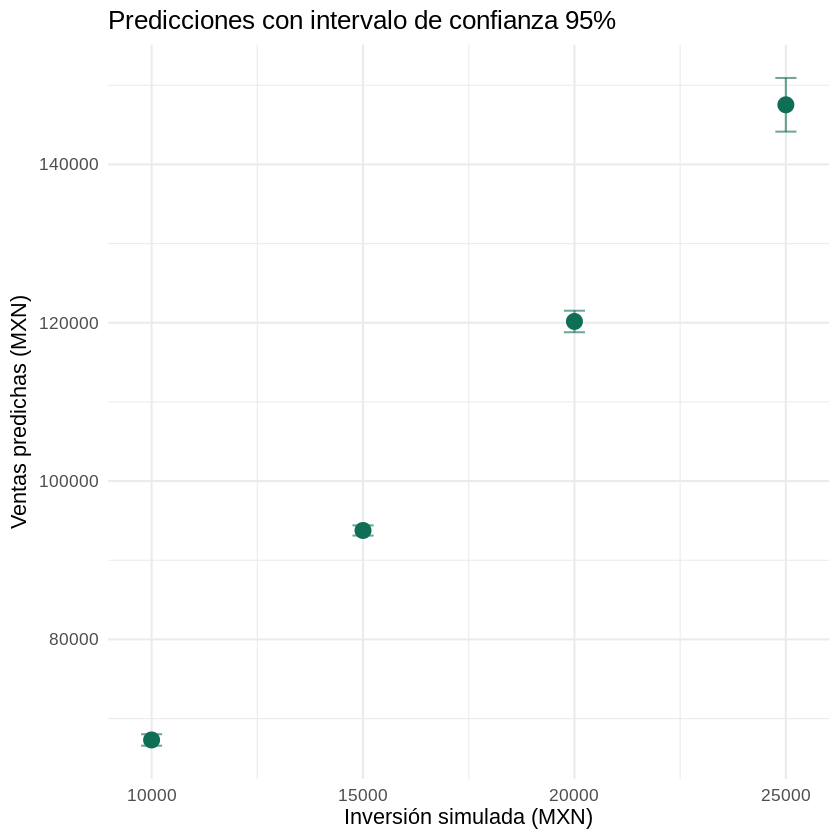

In [6]:
# Predecir ventas para nuevos valores de inversión
nuevos_datos <- data.frame(
  Inversion_Publicidad = c(10000, 15000, 20000, 25000),
  Num_Vendedores       = c(11, 12, 14, 15),
  Satisfaccion_Cliente = c(8.0, 8.5, 9.0, 9.2)
)

predicciones <- predict(modelo_multiple, nuevos_datos,
                        interval = "confidence", level = 0.95)

resultados <- cbind(nuevos_datos, round(predicciones, 0))
colnames(resultados)[4:6] <- c("Venta_Estimada", "IC_Inferior", "IC_Superior")
print(resultados)

# Visualizar predicciones con IC
ggplot(resultados, aes(x = Inversion_Publicidad,
                       y = Venta_Estimada)) +
  geom_point(size = 4, color = "#0F6E56") +
  geom_errorbar(aes(ymin = IC_Inferior, ymax = IC_Superior),
                width = 500, color = "#0F6E56", alpha = 0.6) +
  labs(title = "Predicciones con intervalo de confianza 95%",
       x = "Inversión simulada (MXN)",
       y = "Ventas predichas (MXN)") +
  theme_minimal(base_size = 13)

# A tibble: 3 × 7
  Region Ventas_Total Ventas_Promedio Inversion_Total Satisfaccion_Prom Meses
  <chr>         <dbl>           <dbl>           <dbl>             <dbl> <int>
1 Centro      1084000           83385          169500              8.28    13
2 Norte        484000           80667           75000              8.2      6
3 Sur          352000           70400           52500              7.94     5
# ℹ 1 more variable: Eficiencia <dbl>


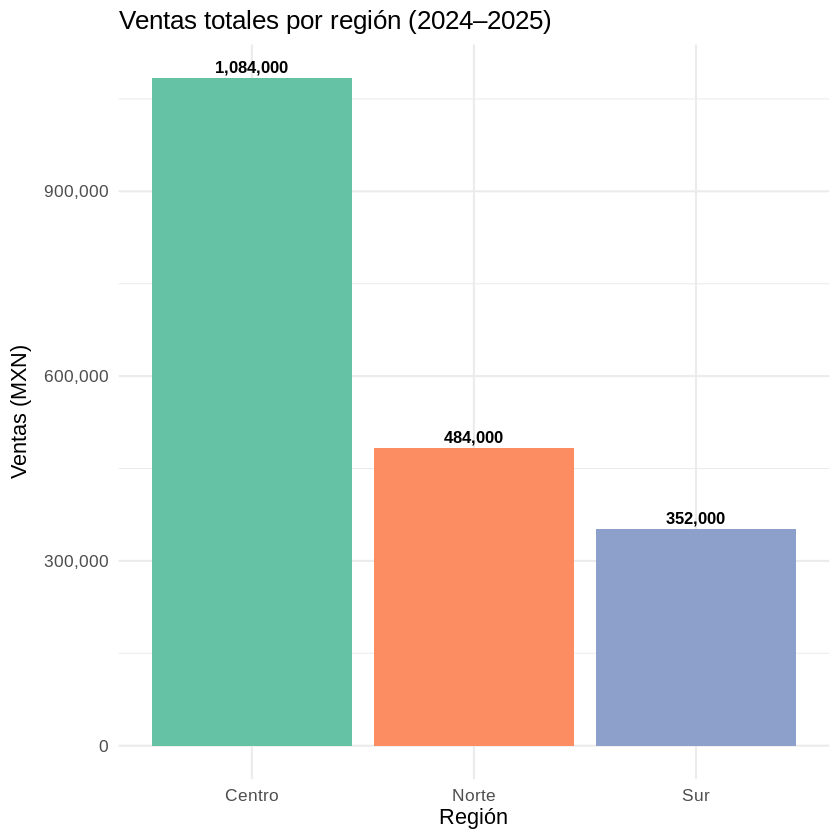

In [7]:
# Resumen por región
resumen_region <- datos |>
  group_by(Region) |>
  summarise(
    Ventas_Total      = sum(Ventas),
    Ventas_Promedio   = round(mean(Ventas), 0),
    Inversion_Total   = sum(Inversion_Publicidad),
    Satisfaccion_Prom = round(mean(Satisfaccion_Cliente), 2),
    Meses             = n(),
    .groups = "drop"
  ) |>
  mutate(Eficiencia = round(Ventas_Total / Inversion_Total, 2))

print(resumen_region)

# Gráfica de ventas por región
ggplot(resumen_region, aes(x = Region, y = Ventas_Total,
                            fill = Region)) +
  geom_col(show.legend = FALSE) +
  geom_text(aes(label = scales::comma(Ventas_Total)),
            vjust = -0.4, size = 3.5, fontface = "bold") +
  scale_fill_brewer(palette = "Set2") +
  scale_y_continuous(labels = scales::comma) +
  labs(title = "Ventas totales por región (2024–2025)",
       x = "Región", y = "Ventas (MXN)") +
  theme_minimal(base_size = 13)